In [1]:
# 先运行1.3统计样本数量,再运行3.4.2

正在读取数据...
正在绘制热图...


/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


✅ 图片已完美保存至: /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/cnmf_Neutrophils_out_Sample_counts/3.4.NeutrophilscGEP_in_cancer.png


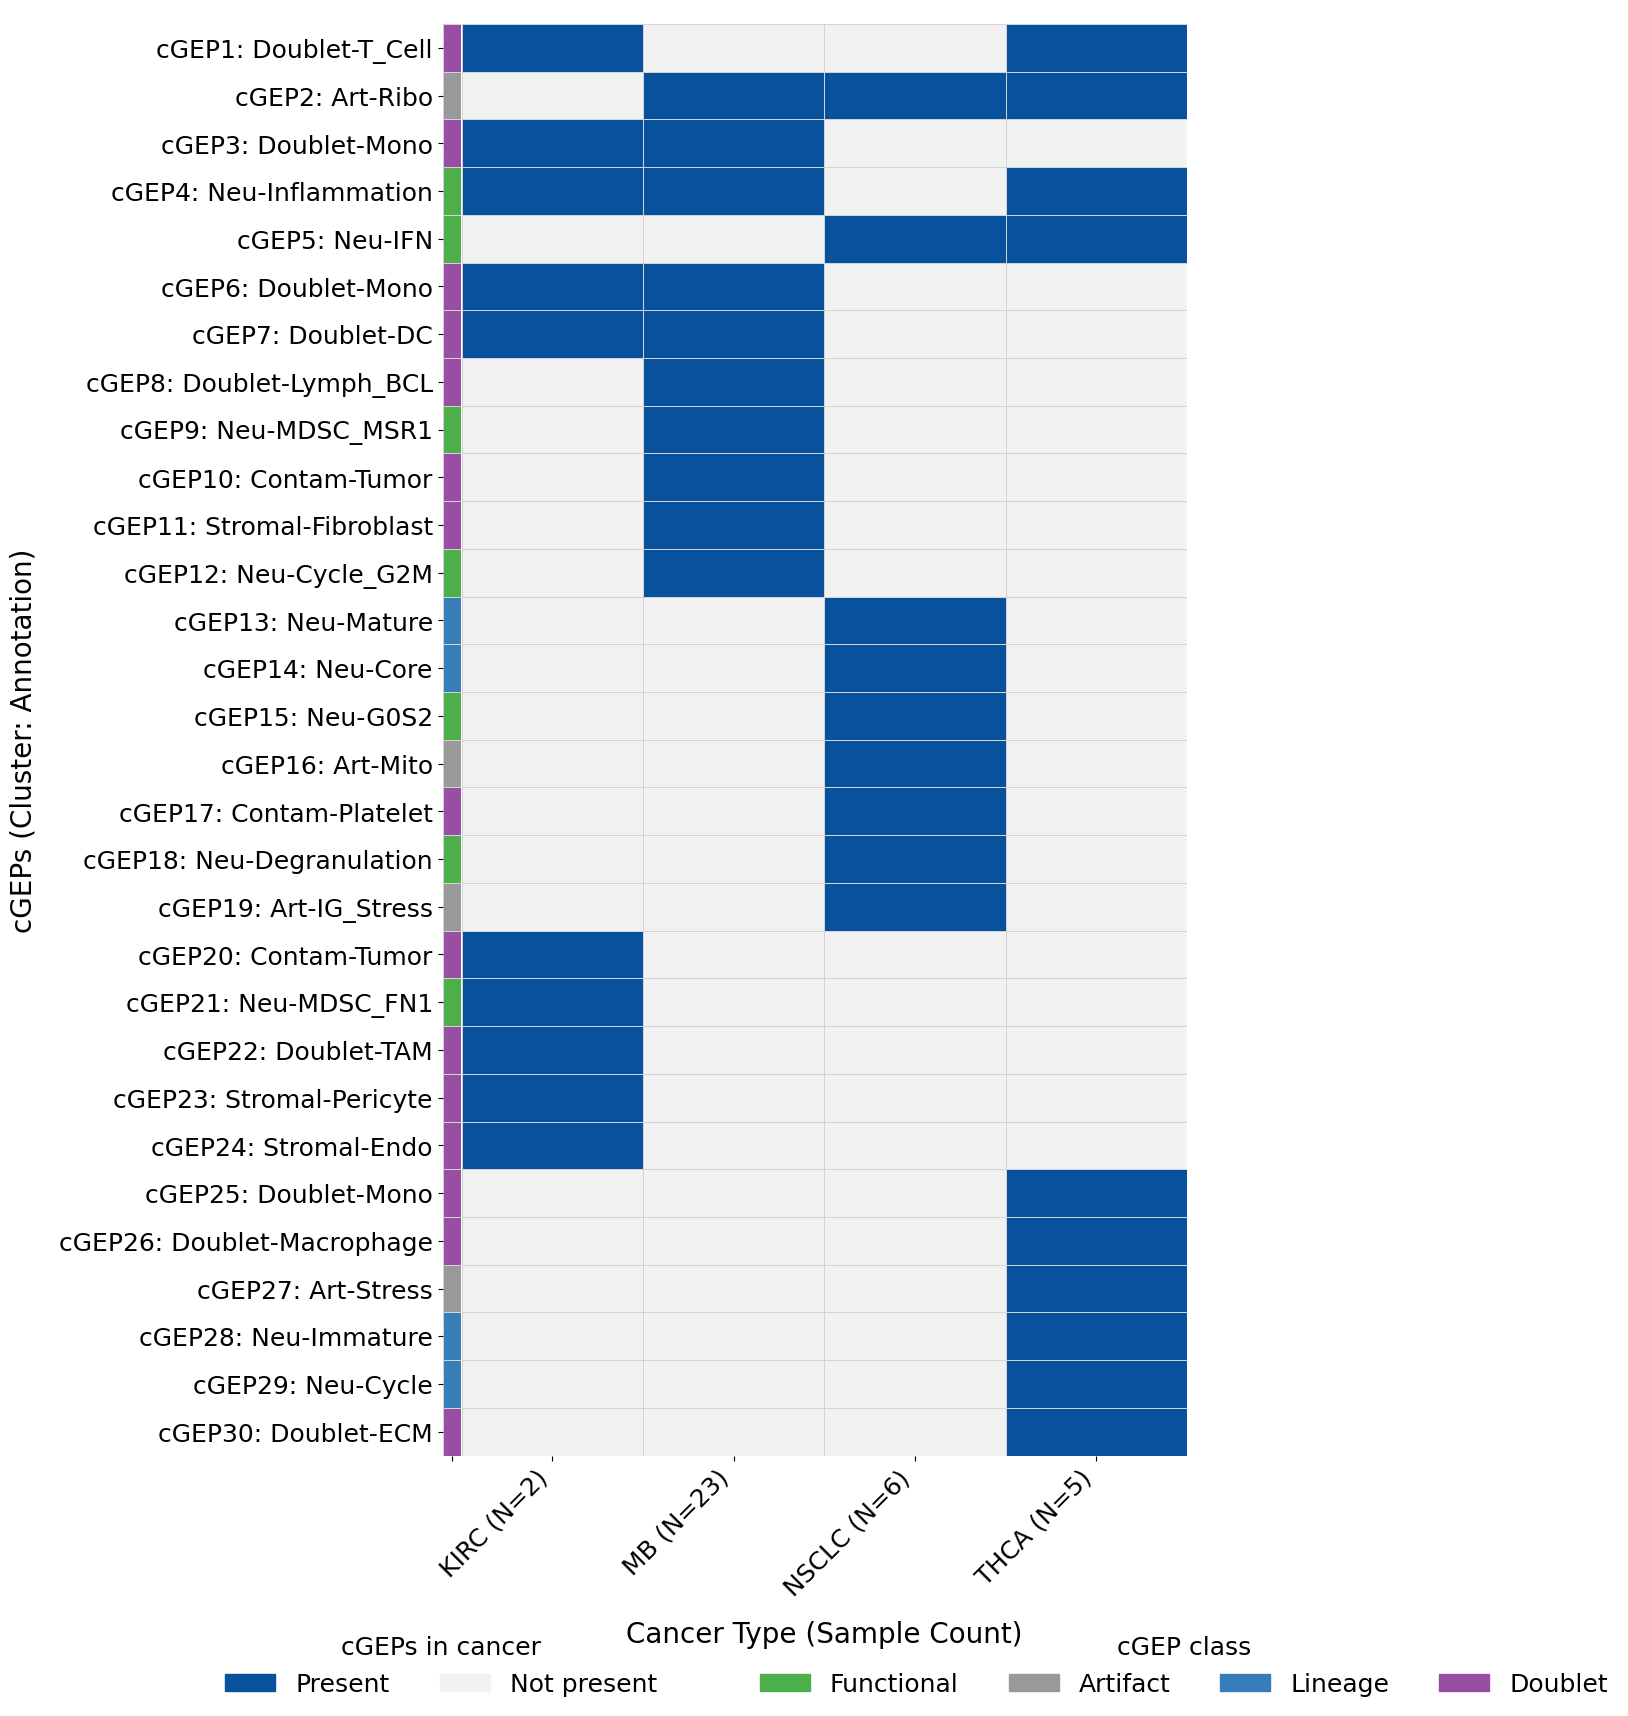

In [74]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# 1. 配置文件路径 (请确保路径准确)
# ==========================================
summary_csv_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/cnmf_Neutrophils_out_Sample_counts/1.3.Neutrophils_dataset_sample_summary.csv' 
gep_txt_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/Example_refbuilder_Neutrophils/starcat_refstarcat_consensus_clustering.txt'
anno_csv_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/3.Neutrophils_GEP_Anno/3.3.Neutrophil_cGEP30_Anno_Complete_With_Genes.csv'

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")
summary_df = pd.read_csv(summary_csv_path)
gep_df = pd.read_csv(gep_txt_path, sep='\t', index_col=0) 
anno_df = pd.read_csv(anno_csv_path)

# ==========================================
# 3. 处理 GEP 注释映射
# ==========================================
anno_df['Display_Label'] = anno_df['cGEP_Cluster'].astype(str) + ": " + anno_df['cGEP_Anno_Name'].astype(str)
cgep_to_label = dict(zip(anno_df['cGEP_Cluster'], anno_df['Display_Label']))
label_to_category = dict(zip(anno_df['Display_Label'], anno_df['Category']))

# ==========================================
# 4. 二值化、合并与聚合
# ==========================================
binary_df = gep_df.notna() & (gep_df != '')
binary_df = binary_df.astype(int).T
binary_df.index.name = 'Dataset'
binary_df = binary_df.reset_index()

binary_df['Dataset'] = binary_df['Dataset'].str.split('_cNMF').str[0]

merged_df = pd.merge(binary_df, summary_df[['Dataset', '癌肿', 'Unique_Sample_Count']], on='Dataset', how='left')
gep_columns = [col for col in merged_df.columns if col.startswith('cGEP')]

agg_dict = {col: 'max' for col in gep_columns}
agg_dict['Unique_Sample_Count'] = 'sum'
grouped_df = merged_df.groupby('癌肿').agg(agg_dict).reset_index()

# ==========================================
# 5. 构建绘图矩阵 (癌肿=行, cGEPs=列)
# ==========================================
grouped_df.index = grouped_df.apply(
    lambda row: f"{row['癌肿']} (N={int(row['Unique_Sample_Count'])})", axis=1
)
plot_df = grouped_df[gep_columns].T
plot_df = plot_df.rename(index=cgep_to_label)

# ==========================================
# 6. 配置左侧分类颜色条 
# ==========================================
category_colors = {
    "Functional": "#4daf4a",
    "Artifact": "#999999",
    "Lineage": "#377eb8",
    "Doublet": "#984ea3"
}

row_category = pd.Series(plot_df.index).map(label_to_category)
row_category.index = plot_df.index
row_colors = row_category.map(category_colors).fillna('#FFFFFF') 

# ==========================================
# 7. 绘制排版热图
# ==========================================
print("正在绘制热图...")

g = sns.clustermap(
    plot_df, 
    cmap=['#F2F2F2', '#08519C'], 
    row_colors=row_colors,       
    row_cluster=False,           
    col_cluster=False,           
    linewidths=0.5, 
    linecolor='lightgray',
    figsize=(10, 15),            
    cbar_pos=None,
    square=True,  
    colors_ratio=0.025,
    dendrogram_ratio=0.01        
)

# 给注释条加网格线切成方块
for collection in g.ax_row_colors.collections:
    collection.set_edgecolor('lightgray')  
    collection.set_linewidth(0.5)          

# 坐标轴排版
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=18)
g.ax_heatmap.set_xlabel("Cancer Type (Sample Count)", fontsize=20, labelpad=15)

g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_ylabel("")

g.ax_row_colors.set_yticks(np.arange(len(plot_df)) + 0.5)
g.ax_row_colors.set_yticklabels(plot_df.index, rotation=0, fontsize=18)
g.ax_row_colors.yaxis.tick_left() 
g.ax_row_colors.set_ylabel("cGEPs (Cluster: Annotation)", fontsize=20, labelpad=15)

# ==========================================
# 8. 添加底部居中双图注 (单行 6 列平铺)
# ==========================================
# 1. 存在性图例 (靠左边，排 2 列)
presence_patches = [
    mpatches.Patch(color='#08519C', label='Present'),
    mpatches.Patch(color='#F2F2F2', label='Not present')
]
legend1 = g.ax_heatmap.legend(
    handles=presence_patches, 
    title="cGEPs in cancer", 
    title_fontsize=18, 
    fontsize=18, 
    loc='upper right',           # 🌟 锚点设在图例的右上角（让图例向左延伸）
    bbox_to_anchor=(0.30, -0.11),# 🌟 与轴的距离
    ncol=2,                      # 🌟 强制水平排成 2 列
    frameon=False
)

# 2. 分类颜色图例 (靠右边，排 4 列)
category_patches = [
    mpatches.Patch(color=color, label=cat) 
    for cat, color in category_colors.items()
]

g.ax_heatmap.add_artist(legend1) # 保留第一个图例

g.ax_heatmap.legend(
    handles=category_patches, 
    title="cGEP class", 
    title_fontsize=18, 
    fontsize=18, 
    loc='upper left',            # 🌟 锚点设在图例的左上角（让图例向右延伸）
    bbox_to_anchor=(0.38, -0.11),# 🌟 X=0.52 (中心偏右)，Y=-0.15 (高度与左边绝对一致)
    ncol=4,                      # 🌟 强制水平排成 4 列
    frameon=False  
)

# ==========================================
# 9. 保存与展示
# ==========================================
# 确保加上 bbox_inches='tight'，防止底部的图注被裁切
#save_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/cnmf_Neutrophils_out_Sample_counts/3.4.NeutrophilscGEP_in_cancer.png'
#plt.savefig(save_path, bbox_inches='tight')
#print(f"✅ 图片已完美保存至: {save_path}")

plt.show()


正在读取数据...
正在绘制热图...


/sibcb1/bioinformatics/yangyue/miniconda3/envs/R4.2/lib/python3.10/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


✅ 图片已完美保存至: /sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/cnmf_Neutrophils_out_Sample_counts/3.4.NeutrophilscGEP_in_cancer.png


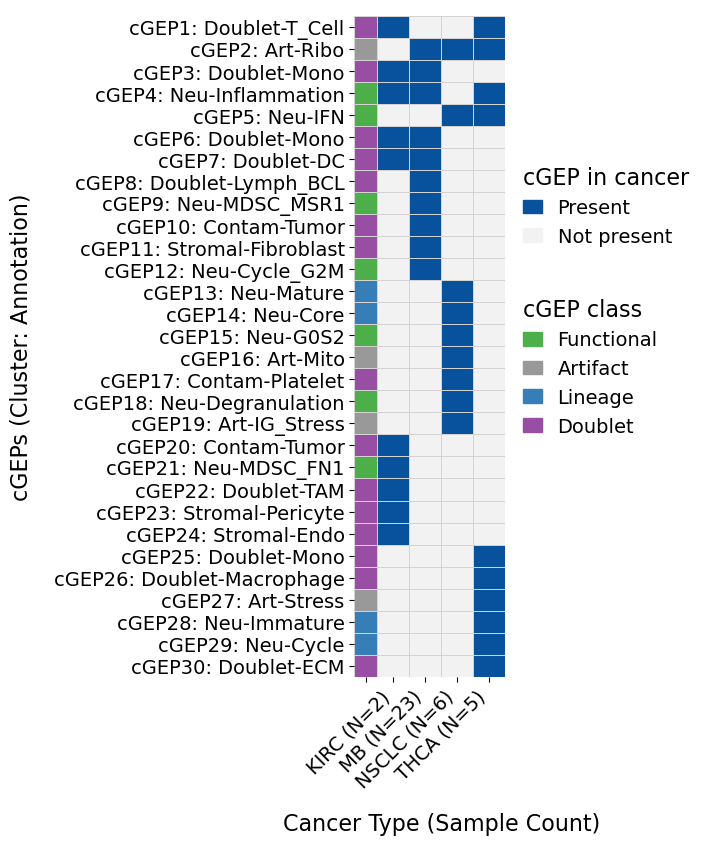

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ==========================================
# 1. 配置文件路径
# ==========================================
summary_csv_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/cnmf_Neutrophils_out_Sample_counts/1.3.Neutrophils_dataset_sample_summary.csv' 
gep_txt_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/Example_refbuilder_Neutrophils/starcat_refstarcat_consensus_clustering.txt'
anno_csv_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/3.Neutrophils_GEP_Anno/3.3.Neutrophil_cGEP30_Anno_Complete_With_Genes.csv'

# ==========================================
# 2. 读取数据
# ==========================================
print("正在读取数据...")
summary_df = pd.read_csv(summary_csv_path)
gep_df = pd.read_csv(gep_txt_path, sep='\t', index_col=0) 
anno_df = pd.read_csv(anno_csv_path)

# ==========================================
# 3. 处理 GEP 注释映射
# ==========================================
anno_df['Display_Label'] = anno_df['cGEP_Cluster'].astype(str) + ": " + anno_df['cGEP_Anno_Name'].astype(str)
cgep_to_label = dict(zip(anno_df['cGEP_Cluster'], anno_df['Display_Label']))
label_to_category = dict(zip(anno_df['Display_Label'], anno_df['Category']))

# ==========================================
# 4. 二值化、合并与聚合
# ==========================================
binary_df = gep_df.notna() & (gep_df != '')
binary_df = binary_df.astype(int).T
binary_df.index.name = 'Dataset'
binary_df = binary_df.reset_index()

binary_df['Dataset'] = binary_df['Dataset'].str.split('_cNMF').str[0]

merged_df = pd.merge(binary_df, summary_df[['Dataset', '癌肿', 'Unique_Sample_Count']], on='Dataset', how='left')
gep_columns = [col for col in merged_df.columns if col.startswith('cGEP')]

agg_dict = {col: 'max' for col in gep_columns}
agg_dict['Unique_Sample_Count'] = 'sum'
grouped_df = merged_df.groupby('癌肿').agg(agg_dict).reset_index()

# ==========================================
# 5. 构建绘图矩阵
# ==========================================
grouped_df.index = grouped_df.apply(
    lambda row: f"{row['癌肿']} (N={int(row['Unique_Sample_Count'])})", axis=1
)
plot_df = grouped_df[gep_columns].T
plot_df = plot_df.rename(index=cgep_to_label)

# ==========================================
# 6. 配置左侧分类颜色条 
# ==========================================
category_colors = {
    "Functional": "#4daf4a",
    "Artifact": "#999999",
    "Lineage": "#377eb8",
    "Doublet": "#984ea3"
}

row_category = pd.Series(plot_df.index).map(label_to_category)
row_category.index = plot_df.index
row_colors = row_category.map(category_colors).fillna('#FFFFFF') 

# ==========================================
# 7. 绘制排版热图
# ==========================================
print("正在绘制热图...")

g = sns.clustermap(
    plot_df, 
    cmap=['#F2F2F2', '#08519C'], 
    row_colors=row_colors,       
    row_cluster=False,           
    col_cluster=False,           
    linewidths=0.5, 
    linecolor='lightgray',
    figsize=(4, 8),            
    cbar_pos=None,  
    colors_ratio=0.15,
    dendrogram_ratio=0.01,
    square=True
)

# 给注释条加网格线切成方块
for collection in g.ax_row_colors.collections:
    collection.set_edgecolor('lightgray')  
    collection.set_linewidth(0.5)          

# 坐标轴排版
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=14)
g.ax_heatmap.set_xlabel("Cancer Type (Sample Count)", fontsize=16, labelpad=15)

g.ax_heatmap.set_yticks([])
g.ax_heatmap.set_ylabel("")

g.ax_row_colors.set_yticks(np.arange(len(plot_df)) + 0.5)
g.ax_row_colors.set_yticklabels(plot_df.index, rotation=0, fontsize=14)
g.ax_row_colors.yaxis.tick_left() 
g.ax_row_colors.set_ylabel("cGEPs (Cluster: Annotation)", fontsize=16, labelpad=15)

# ==========================================
# 8. 添加高级图注
# ==========================================
presence_patches = [
    mpatches.Patch(color='#08519C', label='Present'),
    mpatches.Patch(color='#F2F2F2', label='Not present')
]
legend1 = g.ax_heatmap.legend(
    handles=presence_patches, title="cGEP in cancer", 
    title_fontsize=16, fontsize=14, loc='upper left', 
    bbox_to_anchor=(1, 0.8), frameon=False,
    handlelength=1,alignment='left'
)

category_patches = [
    mpatches.Patch(color=color, label=cat) 
    for cat, color in category_colors.items()
]
g.ax_heatmap.add_artist(legend1) 
g.ax_heatmap.legend(
    handles=category_patches, title="cGEP class", 
    title_fontsize=16, fontsize=14, loc='upper left', 
    bbox_to_anchor=(1, 0.6), frameon=False,
    handlelength=1,alignment='left'
)

# ==========================================
# 9. 保存与展示
# ==========================================
# 确保加上 bbox_inches='tight'，不让外挂的图例被切掉
save_path = '/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/cnmf_Neutrophils_out_Sample_counts/3.4.NeutrophilscGEP_in_cancer.png'
plt.savefig(save_path, bbox_inches='tight')
print(f"✅ 图片已完美保存至: {save_path}")

plt.show()